In [1]:
import pandas as pd
import numpy as np
import plotly.io as pio

In [2]:
df=pd.read_csv('diabetes.csv')

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.shape

(768, 9)

In [9]:
cols_with_zeros=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros]=df[cols_with_zeros].replace(0, np.nan)

df['Glucose']=df['Glucose'].fillna(df['Glucose'].mean())

df['BMI']=df['BMI'].fillna(df['BMI'].median())
df['BloodPressure']=df['BloodPressure'].fillna(df['BloodPressure'].median())
df['SkinThickness']=df['SkinThickness'].fillna(df['SkinThickness'].median())
df['Insulin']=df['Insulin'].fillna(df['Insulin'].median())

In [10]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 6.7 MB/s eta 0:00:00
  Attempting uninstall: kaleido
    Found existing installation: kaleido 1.2.0
    Uninstalling kaleido-1.2.0:
      Successfully uninstalled kaleido-1.2.0


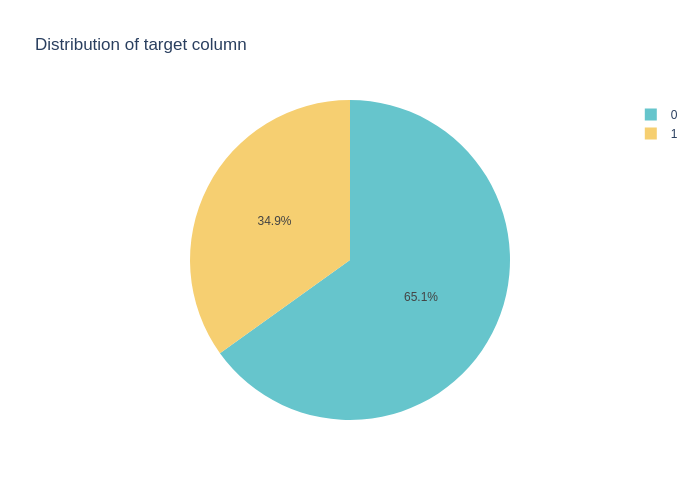

In [12]:
import plotly.express as px
import plotly.graph_objects as go

pio.renderers.default = "png"

fig_balance=px.pie(df, names='Outcome', title='Distribution of target column',
             color_discrete_sequence=px.colors.qualitative.Pastel)
fig_balance.show()


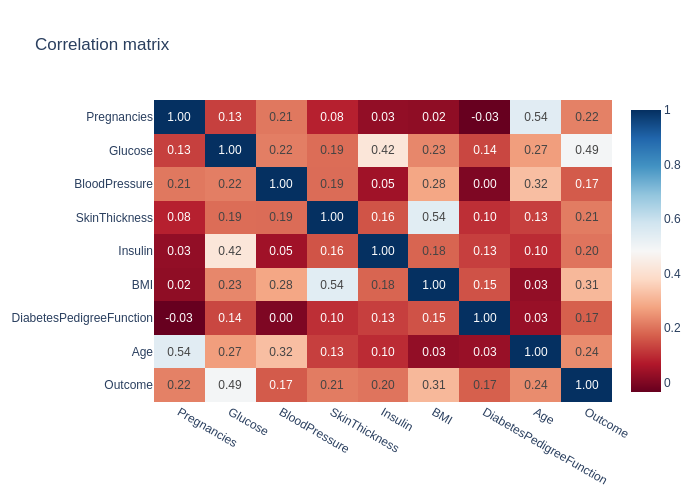

In [13]:
pio.renderers.default = "png"

corr=df.corr()
fig_corr=px.imshow(corr, text_auto='.2f', aspect="auto",
                title="Correlation matrix",
                color_continuous_scale='RdBu')
fig_corr.show()

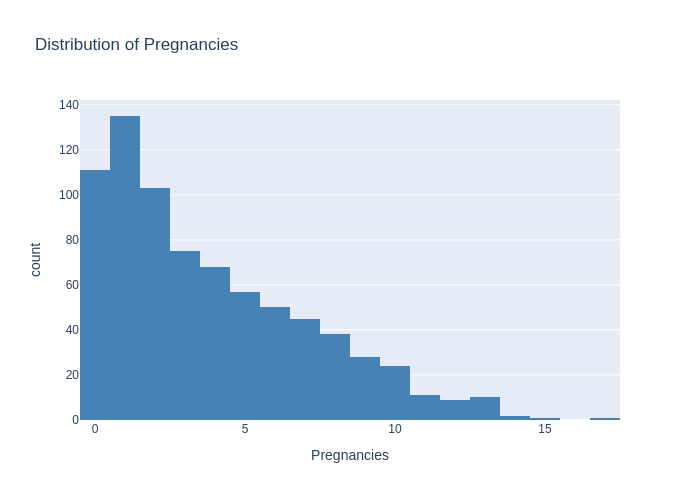

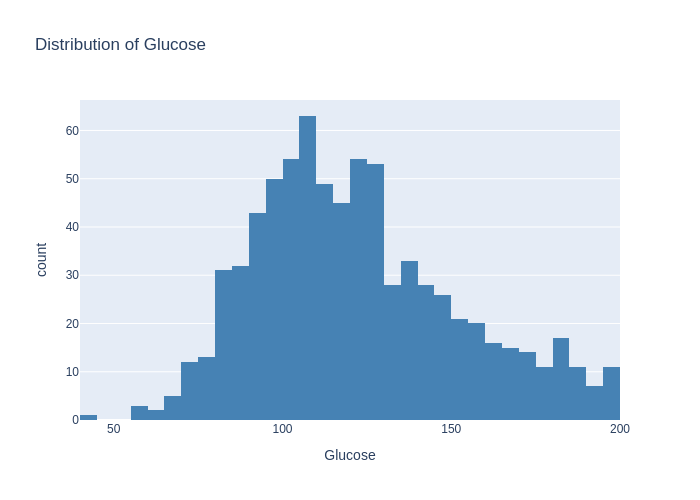

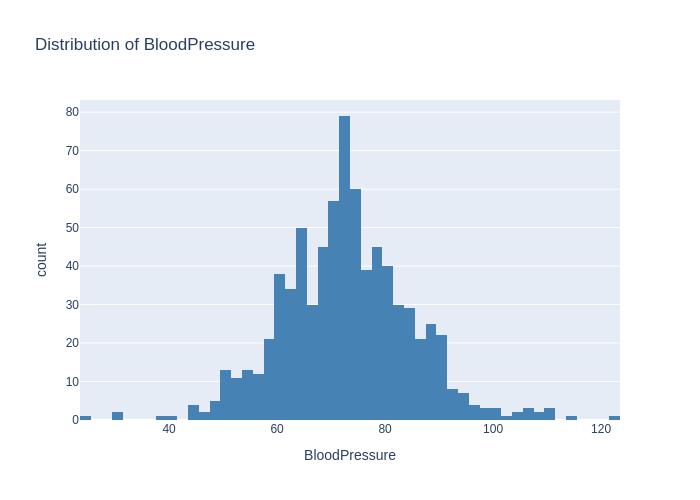

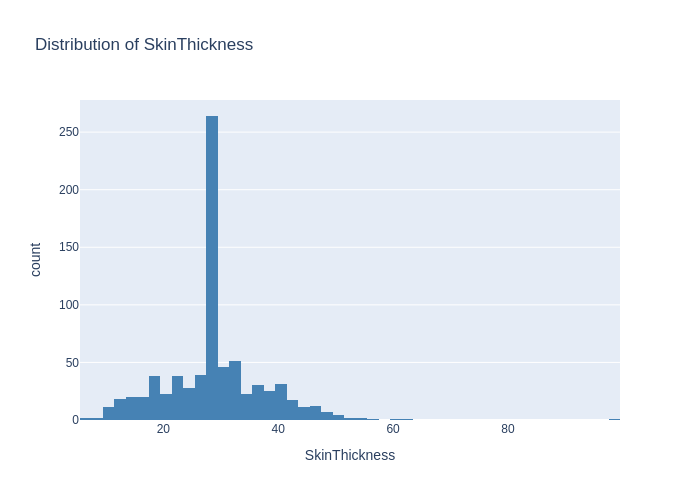

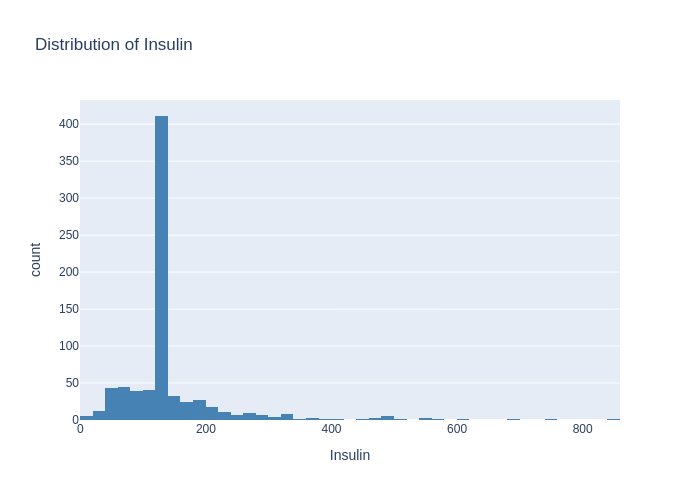

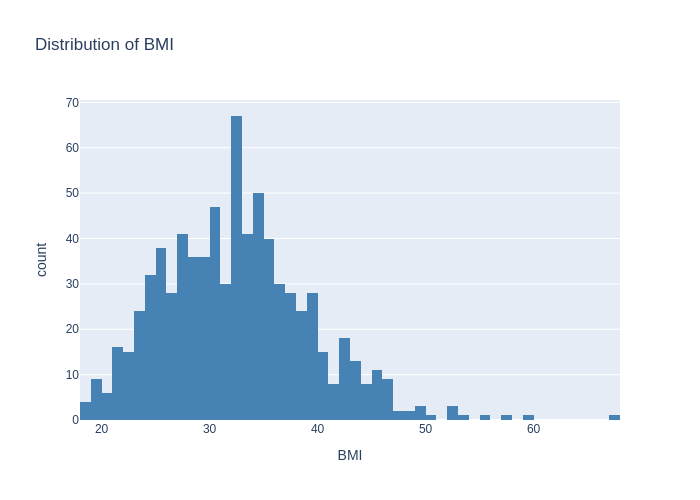

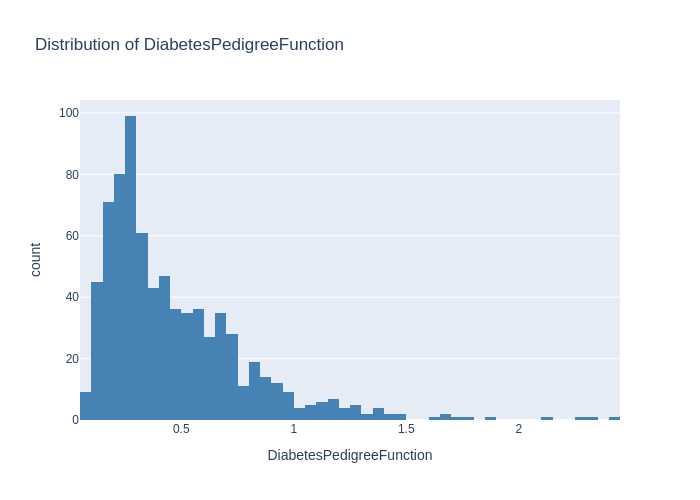

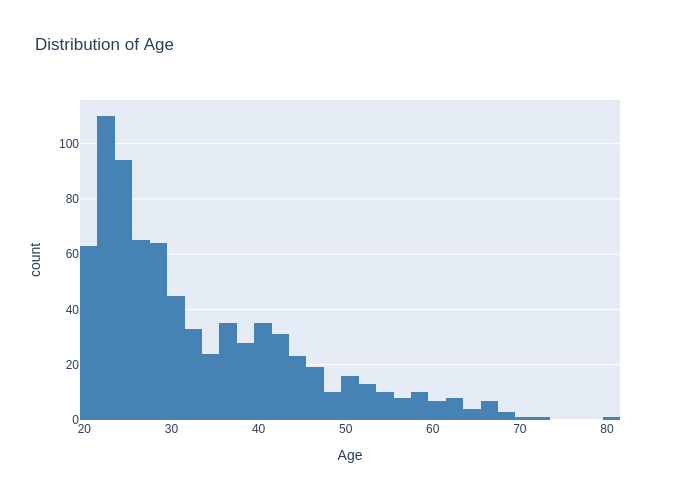

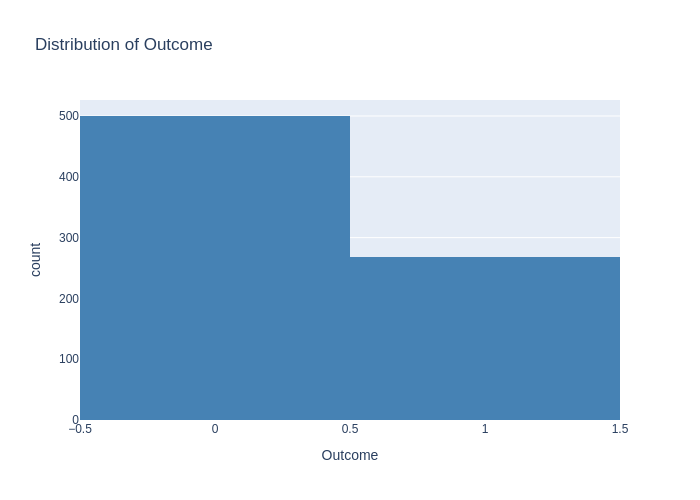

In [26]:
pio.renderers.default = "png"

num_cols=df.select_dtypes(include=np.number).columns.tolist()

for col in num_cols:
    fig=px.histogram(df, x=col, title=f'Distribution of {col}',
                       color_discrete_sequence=['steelblue'])
    fig.show()

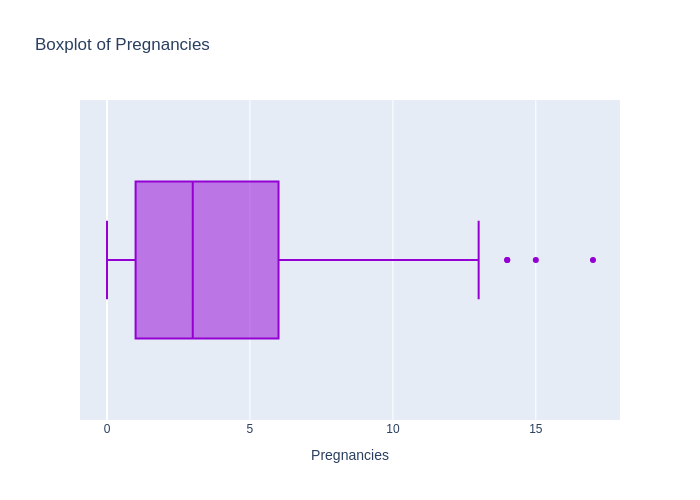

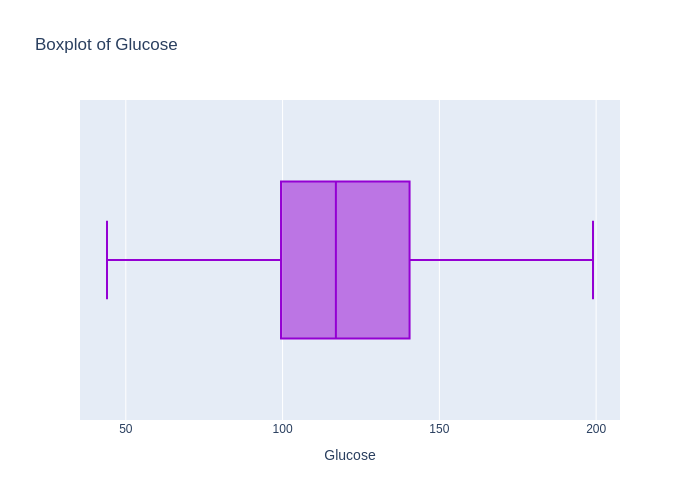

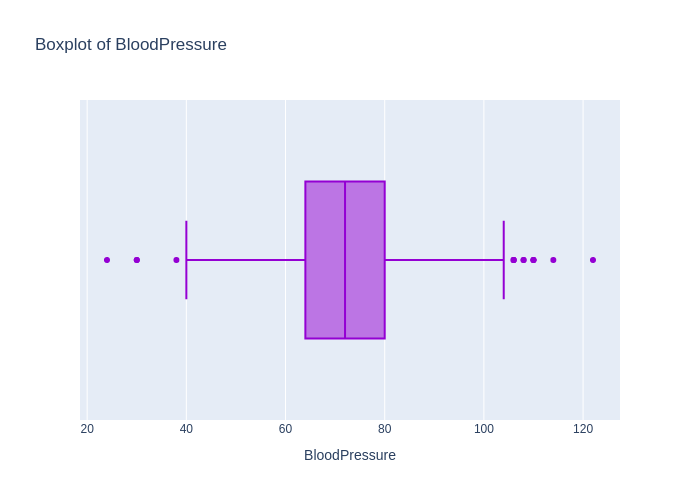

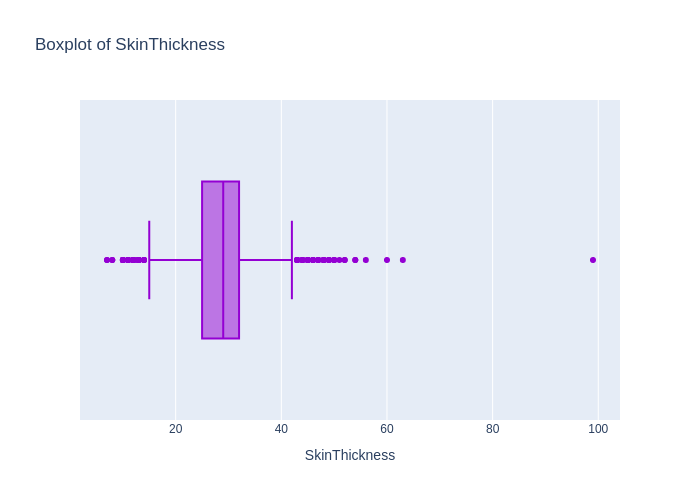

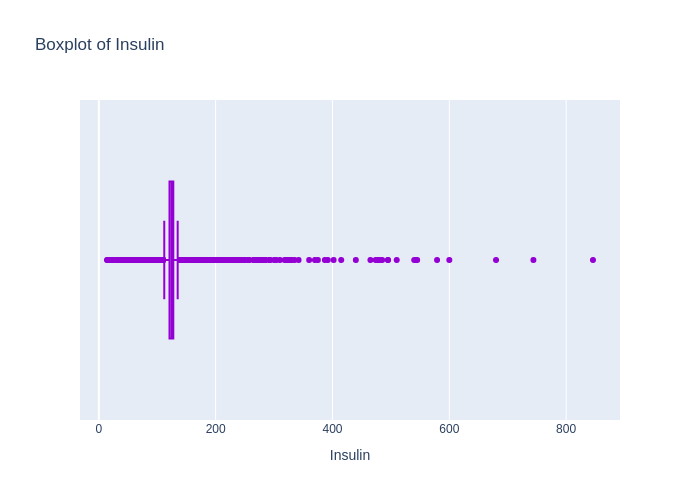

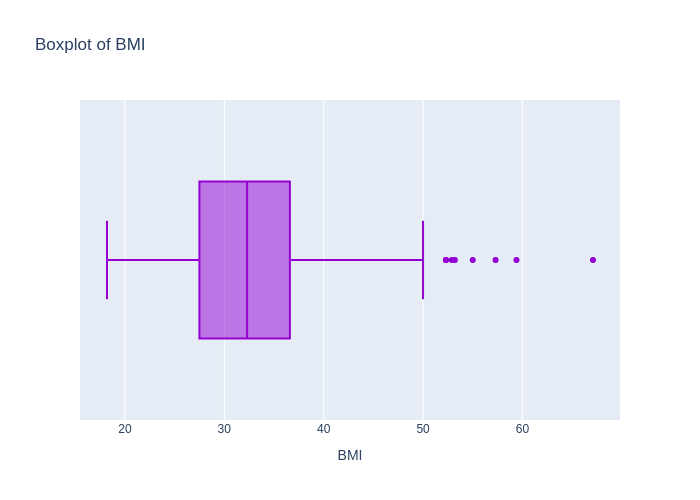

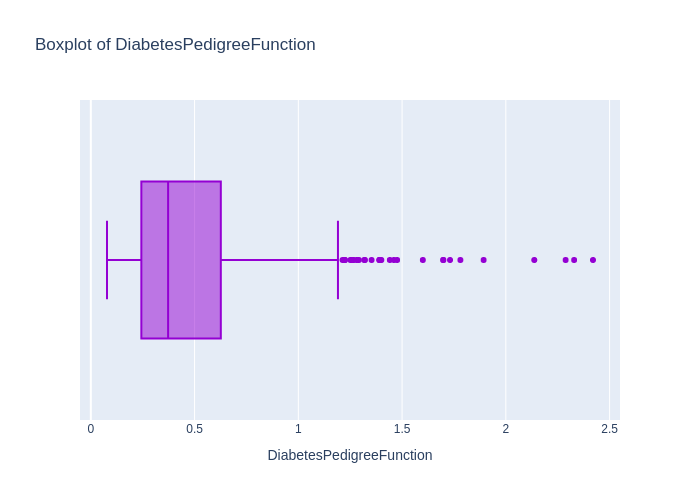

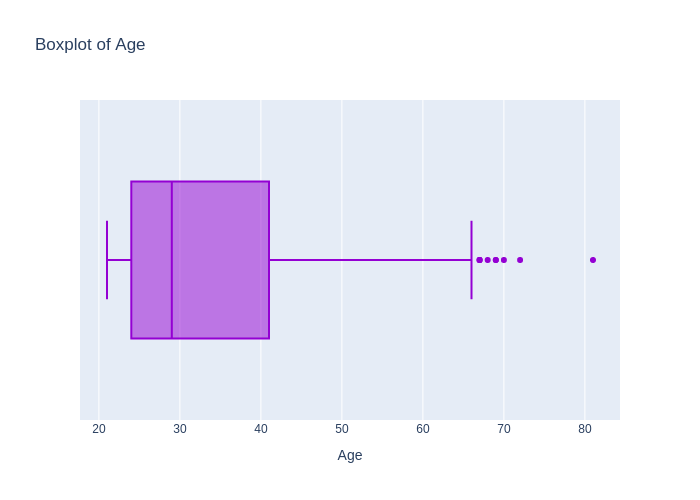

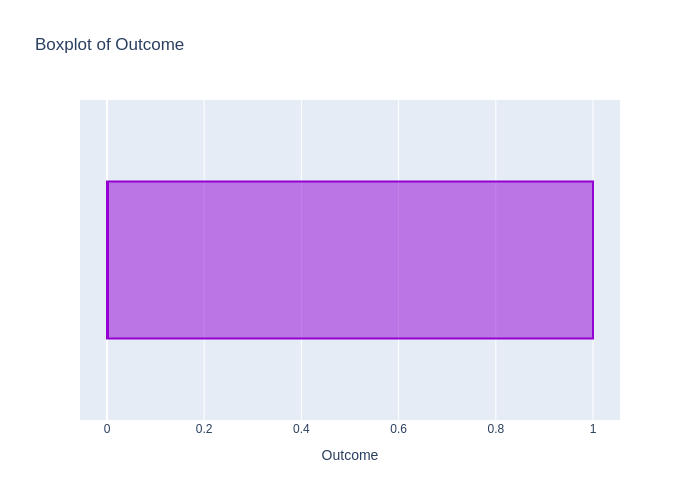

In [27]:
pio.renderers.default = "png"

for col in num_cols:
    fig=px.box(df, x=col, title=f'Boxplot of {col}',
                 color_discrete_sequence=['darkviolet'])
    fig.show()


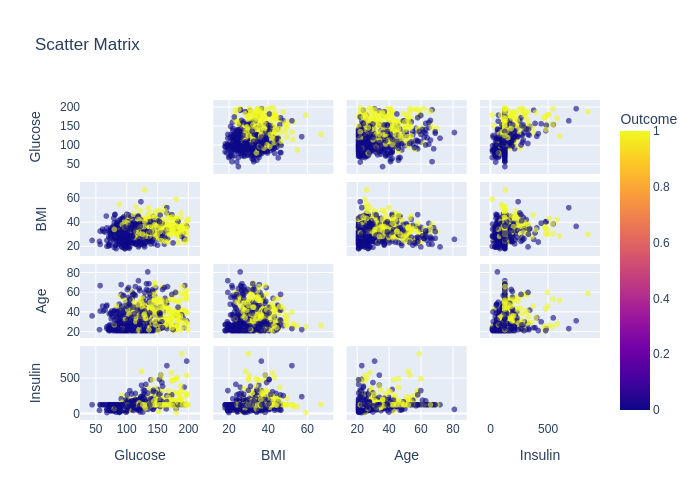

In [16]:
pio.renderers.default = "png"

fig_scatter = px.scatter_matrix(df,
    dimensions=["Glucose", "BMI", "Age", "Insulin"],
    color="Outcome",
    title="Scatter Matrix",
    labels={col: col for col in df.columns},
    opacity=0.6)

fig_scatter.update_traces(diagonal_visible=False)
fig_scatter.show()

In [18]:
#Baseline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

X=df.drop('Outcome', axis=1)
y=df['Outcome']

X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models={
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost":XGBClassifier(eval_metric='logloss', random_state=42)
}

baseline_results=[]

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred=model.predict(X_test)
    y_prob=model.predict_proba(X_test)[:, 1]

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

results_df=pd.DataFrame(baseline_results).sort_values(by='F1 Score', ascending=False)
print("Baseline Results (No Preprocessing / No Tuning):")
display(results_df.round(3))

Baseline Results (No Preprocessing / No Tuning):


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest,0.753,0.667,0.593,0.627,0.817
5,XGBoost,0.753,0.667,0.593,0.627,0.817
0,Logistic Regression,0.701,0.587,0.500,0.540,0.813
3,SVM,0.721,0.649,0.444,0.527,0.781
2,KNN,0.682,0.551,0.500,0.524,0.702
4,Decision Tree,0.675,0.543,0.463,0.500,0.626


In [19]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

param_grids = {
    "Logistic Regression": {
        "clf__C": np.logspace(-3, 3, 7),
        "clf__penalty": ["l2"]
    },
    "Random Forest": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5, 10]
    },
    "KNN": {
        "clf__n_neighbors": range(3, 21),
        "clf__weights": ["uniform", "distance"]
    },
    "SVM": {
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": ["scale", "auto"],
        "clf__kernel": ["rbf", "linear"]
    },
    "Decision Tree": {
        "clf__max_depth": [None, 5, 10, 15],
        "clf__min_samples_split": [2, 10, 20]
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__max_depth": [3, 5, 7]
    }
}

tuned_results=[]
best_models_minmax={}

for name, model in models.items():
    print(f"Searching...: {name}...")

    pipe=Pipeline([
        ('scaler', MinMaxScaler()),
        ('clf', model)
    ])

    rs=RandomizedSearchCV(
        pipe,
        param_distributions=param_grids[name],
        n_iter=7,
        cv=5,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1
    )

    rs.fit(X_train, y_train)

    best_pipe=rs.best_estimator_
    best_models_minmax[name]=best_pipe

    y_pred=best_pipe.predict(X_test)
    y_prob=best_pipe.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Best Params": rs.best_params_
    })

final_df_min_max=pd.DataFrame(tuned_results).sort_values(by='ROC AUC', ascending=False)
final_df_min_max

Searching...: Logistic Regression...
Searching...: Random Forest...
Searching...: KNN...
Searching...: SVM...
Searching...: Decision Tree...
Searching...: XGBoost...


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
3,SVM,0.707792,0.609756,0.462963,0.526316,0.822870,"{'clf__kernel': 'rbf', 'clf__gamma': 'auto', '..."
5,XGBoost,0.727273,0.642857,0.500000,0.562500,0.814907,"{'clf__n_estimators': 200, 'clf__max_depth': 3..."
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.813148,"{'clf__penalty': 'l2', 'clf__C': 1000.0}"
1,Random Forest,0.740260,0.652174,0.555556,0.600000,0.811111,"{'clf__n_estimators': 200, 'clf__min_samples_s..."
2,KNN,0.746753,0.682927,0.518519,0.589474,0.793611,"{'clf__weights': 'distance', 'clf__n_neighbors..."
4,Decision Tree,0.766234,0.650000,0.722222,0.684211,0.780278,"{'clf__min_samples_split': 20, 'clf__max_depth..."


In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

param_grids = {
    "Logistic Regression": {
        "clf__C": np.logspace(-3, 3, 7),
        "clf__penalty": ["l2"]
    },
    "Random Forest": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5, 10]
    },
    "KNN": {
        "clf__n_neighbors": range(3, 21),
        "clf__weights": ["uniform", "distance"]
    },
    "SVM": {
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": ["scale", "auto"],
        "clf__kernel": ["rbf", "linear"]
    },
    "Decision Tree": {
        "clf__max_depth": [None, 5, 10, 15],
        "clf__min_samples_split": [2, 10, 20]
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__max_depth": [3, 5, 7]
    }
}

tuned_results=[]
best_models_std={}

for name, model in models.items():
    print(f"Searching...: {name}...")

    pipe=Pipeline([
        ('scaler',StandardScaler()),
        ('clf', model)
    ])

    rs=RandomizedSearchCV(
        pipe,
        param_distributions=param_grids[name],
        n_iter=7,
        cv=5,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1
    )

    rs.fit(X_train, y_train)

    best_pipe=rs.best_estimator_
    best_models_std[name]=best_pipe

    y_pred=best_pipe.predict(X_test)
    y_prob=best_pipe.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Best Params": rs.best_params_
    })

final_df_std=pd.DataFrame(tuned_results).sort_values(by='ROC AUC', ascending=False)
final_df_std

Searching...: Logistic Regression...
Searching...: Random Forest...
Searching...: KNN...
Searching...: SVM...
Searching...: Decision Tree...
Searching...: XGBoost...


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
5,XGBoost,0.727273,0.642857,0.500000,0.562500,0.814907,"{'clf__n_estimators': 200, 'clf__max_depth': 3..."
3,SVM,0.707792,0.604651,0.481481,0.536082,0.812963,"{'clf__kernel': 'linear', 'clf__gamma': 'scale..."
1,Random Forest,0.746753,0.666667,0.555556,0.606061,0.812778,"{'clf__n_estimators': 200, 'clf__min_samples_s..."
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812778,"{'clf__penalty': 'l2', 'clf__C': 1.0}"
2,KNN,0.727273,0.642857,0.500000,0.562500,0.806481,"{'clf__weights': 'uniform', 'clf__n_neighbors'..."
4,Decision Tree,0.766234,0.650000,0.722222,0.684211,0.779074,"{'clf__min_samples_split': 20, 'clf__max_depth..."


In [21]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

def decimal_scaler(X):
    max_abs=np.max(np.abs(X), axis=0)
    max_abs = np.where(max_abs == 0, 1, max_abs)
    digits=np.ceil(np.log10(max_abs))
    return X / (10**digits)

preprocessors={
    "Quantile": QuantileTransformer(output_distribution='normal', random_state=42),
    "PCA": Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=5))]),
    "LDA": Pipeline([('sc', StandardScaler()), ('lda', LDA())]),
    "Decimal": FunctionTransformer(decimal_scaler)
}

all_results=[]
best_models_advanced={}

for proc_name, proc_obj in preprocessors.items():
    print(f"Preprocessing {proc_name}")

    for model_name, model in models.items():
        pipe=Pipeline([
            ('pre', proc_obj),
            ('clf', model)
        ])

        grid=param_grids[model_name]

        rs=RandomizedSearchCV(pipe, grid, n_iter=7, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1)

        rs.fit(X_train, y_train)

        best_model=rs.best_estimator_
        best_models_advanced[(proc_name, model_name)]=best_model
        y_pred=best_model.predict(X_test)
        y_prob=best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else y_pred

        all_results.append({
            "Preprocessing": proc_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC_AUC": roc_auc_score(y_test, y_prob)
        })

full_report=pd.DataFrame(all_results)
display(full_report.sort_values(by='ROC_AUC', ascending=False).round(3))

Preprocessing Quantile


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning:

n_quantiles (1000) is greater than the total number of samples (614). n_quantiles is set to n_samples.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning:

n_quantiles (1000) is greater than the total number of samples (614). n_quantiles is set to n_samples.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning:

n_quantiles (1000) is greater than the total number of samples (614). n_quantiles is set to n_samples.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning:

n_quantiles (1000) is greater than the total number of samples (614). n_quantiles is set to n_samples.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning:

n_quantiles (1000) is greater than the total number of samples (614). n_quantiles is set to n_samples.

/usr/local/lib/python3.12

Preprocessing PCA
Preprocessing LDA
Preprocessing Decimal


,Preprocessing,Model,Accuracy,Precision,Recall,F1,ROC_AUC
21,Decimal,SVM,0.708,0.610,0.463,0.526,0.818
5,Quantile,XGBoost,0.727,0.643,0.500,0.562,0.815
23,Decimal,XGBoost,0.727,0.643,0.500,0.562,0.815
19,Decimal,Random Forest,0.747,0.667,0.556,0.606,0.814
0,Quantile,Logistic Regression,0.727,0.630,0.537,0.580,0.812
15,LDA,SVM,0.708,0.605,0.481,0.536,0.812
12,LDA,Logistic Regression,0.656,1.000,0.019,0.036,0.812
3,Quantile,SVM,0.721,0.622,0.519,0.566,0.812
1,Quantile,Random Forest,0.747,0.660,0.574,0.614,0.809
18,Decimal,Logistic Regression,0.701,0.587,0.500,0.540,0.809


In [22]:
def prepare_df(df, stage_name, prep_name):
    temp_df = df.copy()
    temp_df['Stage']=stage_name
    temp_df['Preprocessing']=prep_name

    rename_dict = {
        'F1 Score': 'F1',
        'ROC AUC': 'ROC_AUC'
    }
    temp_df=temp_df.rename(columns=rename_dict)

    target_cols=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Stage', 'Preprocessing']

    available_cols=[c for c in target_cols if c in temp_df.columns]

    return temp_df[available_cols]

df1=prepare_df(results_df, '1. Baseline', 'None')
df2=prepare_df(final_df_min_max, '2. MinMax + Tuning', 'MinMax')
df3=prepare_df(final_df_std, '3. Standard + Tuning', 'Standard')
df4=prepare_df(full_report, '4. Advanced', 'Various')

combined_report=pd.concat([df1, df2, df3, df4], ignore_index=True)

final_table=combined_report.sort_values(by='ROC_AUC', ascending=False).reset_index(drop=True)

print("Final results:")
display(final_table.round(3))

Final results:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Stage,Preprocessing
0,SVM,0.708,0.610,0.463,0.526,0.823,2. MinMax + Tuning,MinMax
1,SVM,0.708,0.610,0.463,0.526,0.818,4. Advanced,Various
2,XGBoost,0.753,0.667,0.593,0.627,0.817,1. Baseline,None
3,Random Forest,0.753,0.667,0.593,0.627,0.817,1. Baseline,None
4,XGBoost,0.727,0.643,0.500,0.562,0.815,3. Standard + Tuning,Standard
5,XGBoost,0.727,0.643,0.500,0.562,0.815,2. MinMax + Tuning,MinMax
6,XGBoost,0.727,0.643,0.500,0.562,0.815,4. Advanced,Various
7,XGBoost,0.727,0.643,0.500,0.562,0.815,4. Advanced,Various
8,Random Forest,0.747,0.667,0.556,0.606,0.814,4. Advanced,Various
9,Logistic Regression,0.701,0.587,0.500,0.540,0.813,1. Baseline,None


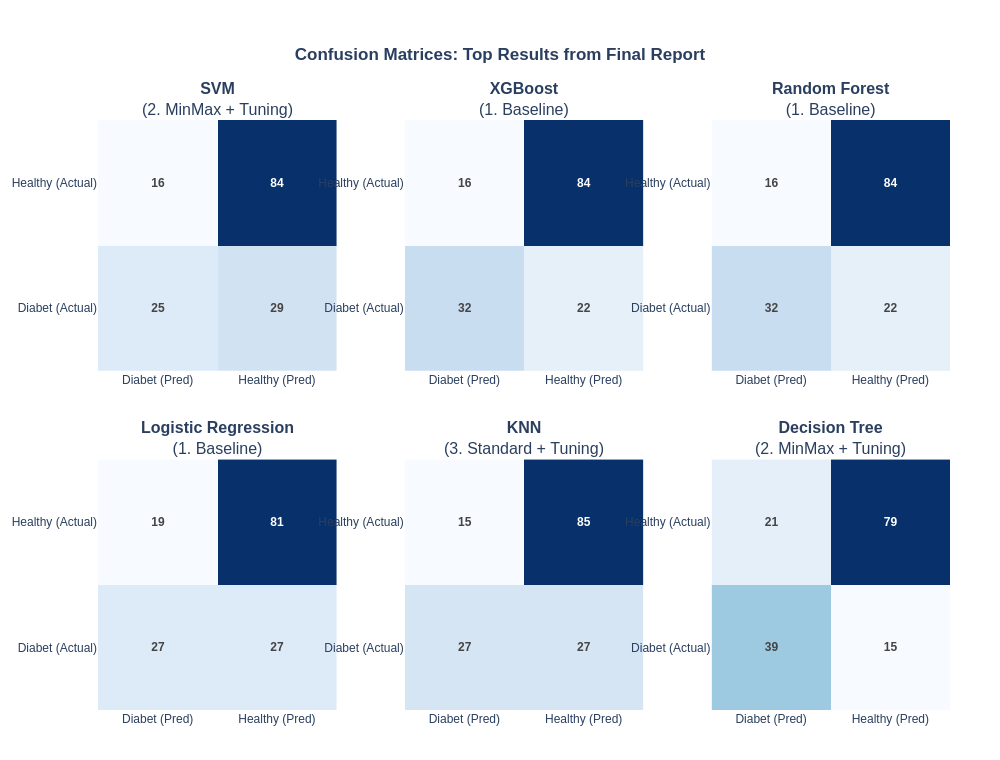

In [23]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import confusion_matrix

pio.renderers.default = "png"

def get_best_pipeline(model_name, stage):
    if '1. Baseline' in stage:
        return models[model_name]
    elif '2. MinMax' in stage:
        return best_models_minmax[model_name]
    elif '3. Standard' in stage:
        return best_models_std[model_name]
    else:
        adv_rows=combined_report[(combined_report['Model'] == model_name) &
                                   (combined_report['Stage'] == '4. Advanced')]
        best_prep=adv_rows.sort_values('ROC_AUC', ascending=False).iloc[0]['Preprocessing']
        return best_models_advanced[(best_prep, model_name)]

best_results_idx=combined_report.groupby('Model')['ROC_AUC'].idxmax()
top_models_info=combined_report.loc[best_results_idx].sort_values(by='ROC_AUC', ascending=False)

models_to_plot=top_models_info['Model'].tolist()
cols=3
rows=(len(models_to_plot) + cols - 1) // cols

fig_cm = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=[f"<b>{row['Model']}</b><br>({row['Stage']})" for _, row in top_models_info.iterrows()],
    horizontal_spacing=0.08,
    vertical_spacing=0.15
)

for i, (_, row) in enumerate(top_models_info.iterrows()):
    model_name=row['Model']
    stage=row['Stage']

    pipe=get_best_pipeline(model_name, stage)

    y_pred=pipe.predict(X_test)
    cm=confusion_matrix(y_test, y_pred, labels=[1, 0])

    curr_row=(i // cols) + 1
    curr_col=(i % cols) + 1

    heatmap = go.Heatmap(
        z=cm,
        x=['Diabet (Pred)', 'Healthy (Pred)'],
        y=['Diabet (Actual)', 'Healthy (Actual)'],
        colorscale='Blues',
        showscale=False,
        text=cm,
        texttemplate="<b>%{text}</b>",
        hoverinfo="z"
    )

    fig_cm.add_trace(heatmap, row=curr_row, col=curr_col)

fig_cm.update_layout(
    title_text='<b>Confusion Matrices: Top Results from Final Report</b>',
    title_x=0.5,
    height=380 * rows,
    width=1000,
    margin=dict(l=50, r=50, t=120, b=50),
    template='plotly_white'
)

fig_cm.update_xaxes(tickangle=0)
fig_cm.show()

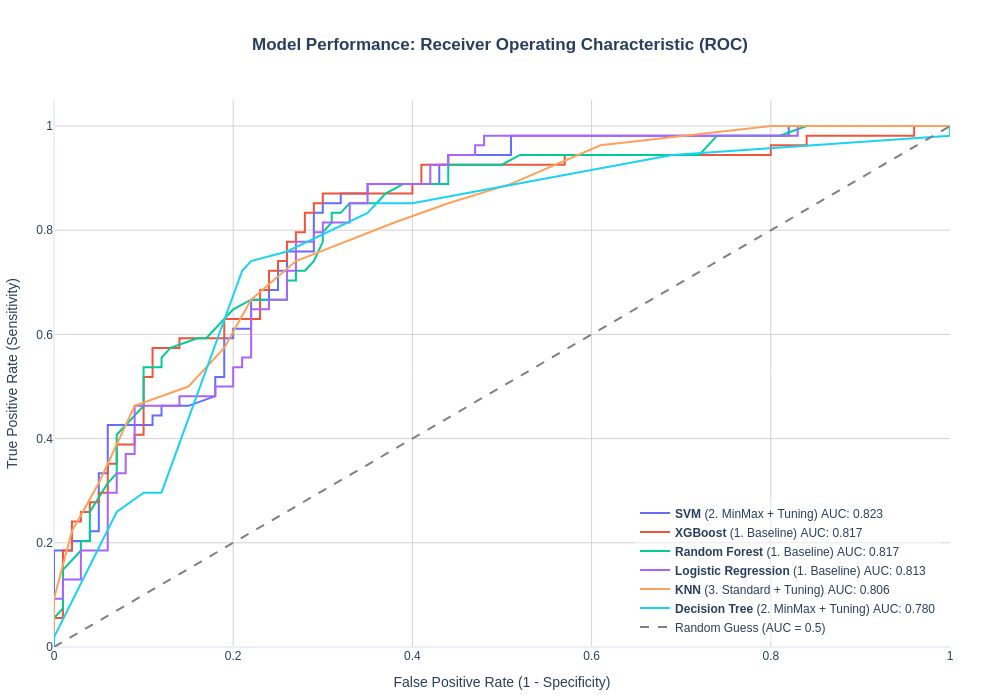

In [25]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

pio.renderers.default = "png"

best_results_idx=combined_report.groupby('Model')['ROC_AUC'].idxmax()
top_models_info=combined_report.loc[best_results_idx].sort_values(by='ROC_AUC', ascending=False)

fig_roc=go.Figure()

for _, row in top_models_info.iterrows():
    model_name=row['Model']
    stage_info=row['Stage']
    pipe=get_best_pipeline(model_name, stage_info)

    if hasattr(pipe, "predict_proba"):
        y_prob=pipe.predict_proba(X_test)[:, 1]
    else:
        y_prob=pipe.decision_function(X_test)

    fpr, tpr, _=roc_curve(y_test, y_prob)
    roc_auc_val=auc(fpr, tpr)

    fig_roc.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode='lines',
        name=f"<b>{model_name}</b> ({stage_info}) AUC: {roc_auc_val:.3f}",
        hovertemplate = f"<b>{model_name}</b><br>FPR: %{{x:.3f}}<br>TPR: %{{y:.3f}}<extra></extra>"
    ))

fig_roc.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(dash='dash', color='grey'),
    name='Random Guess (AUC = 0.5)'
))

fig_roc.update_layout(
    title='<b>Model Performance: Receiver Operating Characteristic (ROC)</b>',
    title_x=0.5,
    xaxis_title='False Positive Rate (1 - Specificity)',
    yaxis_title='True Positive Rate (Sensitivity)',
    xaxis=dict(range=[0, 1], gridcolor='lightgrey'),
    yaxis=dict(range=[0, 1.05], gridcolor='lightgrey'),
    width=1000,
    height=700,
    template='plotly_white',
    legend=dict(
        yanchor="bottom",
        y=0.01,
        xanchor="right",
        x=0.99,
        bgcolor="rgba(255, 255, 255, 0.5)"
    ),
    margin=dict(l=50, r=50, t=100, b=50)
)

fig_roc.show()